In [1]:
!git clone https://github.com/Harsh-SOE/SSNeRF.git

Cloning into 'SSNeRF'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 97 (delta 37), reused 72 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 9.96 MiB | 16.32 MiB/s, done.
Resolving deltas: 100% (37/37), done.


<div style="width: 100%;">
  <h1><tt>Semantic and Silhouette Guided Neural Radiance Fields</tt></h1>
  <p><i>Reconstruction of 3D model from sparse multi-view dataset.</i></p>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
  <p>This interactive notebook delve into the world of <b>Neural Radiance Fields (NeRF)</b> applied to botany. We'll transform a series of 2D images of a plant into a detailed 3D model, complete with semantic segmentation.</p>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
</div>

<div style="width: 100%;">
  <h3><tt>Environment Setup and Dependencies</tt></h3>
  <p><i>Verifying CUDA availability and installing necessary libraries for NeRF and semantic segmentation.</i></p>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
</div>

In [2]:
import subprocess
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)
import torch
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Thu May 14 18:51:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install -q segment-anything open3d trimesh scikit-image scipy tqdm albumentations scikit-learn networkx
!pip install -q matplotlib opencv-python-headless timm fast-simplification ExifRead
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
!pip install rembg[gpu]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 835.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 130.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 6.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 104.4 MB/s et

<div style="width: 100%;">
  <h3><tt>Importing neccessary packages and additional configuation</tt></h3>
</div>

In [1]:
try:
  from pathlib import Path
  import warnings
  import os, math, json, time, zipfile, warnings, random, shutil, gc
  import numpy as np
  import cv2
  import torch
  import matplotlib.pyplot as plt
  import torch.nn.functional as F
  from tqdm import tqdm
  from PIL import Image
  from rembg import new_session
  from google.colab import files
except ImportError as e:
    print(f"Import error: {e}")

warnings.filterwarnings("ignore")

<div style="width: 100%;">
  <h2><tt>Configuration </tt></h2>
</div>

<div style="width: 100%;">
  <h3><tt>Directory setup</tt></h3>
</div>

In [2]:
BASE_DIR      = Path('/content/plant_nerf')
RAW_DIR       = BASE_DIR / 'images_raw'
ALIGNED_RAW_DIR = BASE_DIR / 'images_raw_axis_aligned'
AXIS_DEBUG_DIR  = BASE_DIR / 'axis_debug'
SEGMENTED_DIR = BASE_DIR / 'images_segmented'
RESIZED_DIR   = BASE_DIR / 'images_resized'
MASK_DIR      = BASE_DIR / 'masks'
MASK_VIS_DIR  = BASE_DIR / 'masks_vis'
LABEL_DIR     = BASE_DIR / 'labels'
LABEL_VIS_DIR = BASE_DIR / 'labels_vis'
CKPT_DIR      = BASE_DIR / 'checkpoints'
OUTPUT_DIR    = BASE_DIR / 'output'
DEBUG_DIR     = BASE_DIR / 'debug'

for d in [RAW_DIR,
          RESIZED_DIR,
          ALIGNED_RAW_DIR,
          AXIS_DEBUG_DIR,
          MASK_DIR,
          MASK_VIS_DIR,
          LABEL_DIR,
          LABEL_VIS_DIR,
          CKPT_DIR,
          OUTPUT_DIR,
          SEGMENTED_DIR,
          DEBUG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [3]:
%cd /content/SSNeRF

/content/SSNeRF


In [4]:
from src.config.sam import SAMConfig
from src.config.project import Config
from src.models.arch import SemanticNeRF
from src.models.poses import build_initial_poses
from src.dataset.plant_dataset import PlantDataset
from src.utils.focal_length import extract_focal_length_data
from src.utils.sam_predictor_loader import load_sam_predictor
from src.pre_processing.semantic_label import visualize_top_view
from src.pre_processing.extract_silhouette import extract_silhouette
from src.pre_processing.segmentation import segment_plant_from_raw_images
from src.models.early_stopper import EarlyStopper
from src.config.early_stopping import EarlyStopConfig
from src.losses.semantic_loss import compute_semantic_loss
from src.losses.bg_supression import compute_bg_suppression_loss
from src.losses.total_loss import compute_total_loss
from src.losses.silhouette_loss import compute_silhouette_loss
from src.losses.distortion import compute_distortion_loss
from src.losses.color_loss import compute_color_loss
from src.models.pose_refiner import PoseRefiner
from src.models.arch import volume_render, sample_coarse, sample_fine
from src.pre_processing.alignment import detect_pot_axis_x, align_image_horizontally_to_axis
from src.pre_processing.semantic_label import run_pseudo_label_pipeline, visualize_pipeline_output

In [5]:
cfg = Config()

In [6]:
print(f"Focal Length (px): {cfg.camera.focal_length:.1f}")
print(f"FOV X: {cfg.camera.fov_x_deg:.1f}° | FOV Y: {cfg.camera.fov_y_deg:.1f}°")

print("\nNeRF transforms.json parameters:")
for key, value in cfg.camera.nerf_intrinsics.items():
  # Format floating points for cleaner output
  val_str = f"{value:.4f}" if isinstance(value, float) else value
  print(f"  {key}: {val_str}")

Focal Length (px): 404.3
FOV X: 52.6° | FOV Y: 66.8°

NeRF transforms.json parameters:
  fl_x: 404.3500
  fl_y: 404.3500
  cx: 200.0000
  cy: 266.5000
  w: 400
  h: 533


<div style="width: 100%;">
  <h3><tt>Upload plant images </tt></h3>
</div>

In [ ]:
print(
    f"NOTE: You need to upload "
    f"{cfg.rotation.num_side_views_images} side views images in total "
    f"{'and 1 top view image as well' if cfg.rotation.use_top_view else ''}"
)

for angle in cfg.rotation.rotation_angles:
    print(f'Upload {int(angle/cfg.rotation.angle_period)}/{int(cfg.rotation.num_images)} image')
    image_new_name = f'{angle}.png'
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Please upload exactly one image.")
    image_original_name = next(iter(uploaded))
    src = Path(f"/content/{image_original_name}")
    dest = RAW_DIR / image_new_name
    shutil.move(str(src), str(dest))
    print(f'  Saved: {image_new_name}')

print(f"\n✅ All {cfg.rotation.num_images} images uploaded successfully!")

<div style="width: 100%;">
  <h3><tt>Mount from google drive </tt></h3>
</div>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
DRIVE_DATASET_PATH = "/content/drive/MyDrive/Dataset"
!cp -r "{DRIVE_DATASET_PATH}/." "{RAW_DIR}/"

In [9]:
for file_path in RAW_DIR.glob("*.jpg"):

    original_image_name_stem = file_path.stem
    original_image_name = file_path.name

    last = original_image_name_stem.split("_")[-1]

    if last == "top":
        print(f"Renamed \'{original_image_name}\' to \'top.png\'")
        new_name = "top.png"
        os.rename(os.path.join(RAW_DIR, original_image_name),os.path.join(RAW_DIR, new_name))
    else:
        angle = int(last)
        new_name = f"{angle * 18}.png"
        print(f"Renamed \'{original_image_name}\' to \'{new_name}\'")
        os.rename(os.path.join(RAW_DIR, file_path.name),os.path.join(RAW_DIR, new_name))

Renamed 'plant_angle_top.jpg' to 'top.png'
Renamed 'plant_angle_13.jpg' to '234.png'
Renamed 'plant_angle_7.jpg' to '126.png'
Renamed 'plant_angle_0.jpg' to '0.png'
Renamed 'plant_angle_17.jpg' to '306.png'
Renamed 'plant_angle_14.jpg' to '252.png'
Renamed 'plant_angle_11.jpg' to '198.png'
Renamed 'plant_angle_2.jpg' to '36.png'
Renamed 'plant_angle_9.jpg' to '162.png'
Renamed 'plant_angle_10.jpg' to '180.png'
Renamed 'plant_angle_4.jpg' to '72.png'
Renamed 'plant_angle_19.jpg' to '342.png'
Renamed 'plant_angle_1.jpg' to '18.png'
Renamed 'plant_angle_12.jpg' to '216.png'
Renamed 'plant_angle_15.jpg' to '270.png'
Renamed 'plant_angle_8.jpg' to '144.png'
Renamed 'plant_angle_6.jpg' to '108.png'
Renamed 'plant_angle_3.jpg' to '54.png'
Renamed 'plant_angle_18.jpg' to '324.png'
Renamed 'plant_angle_16.jpg' to '288.png'
Renamed 'plant_angle_5.jpg' to '90.png'


In [10]:
def views_key():
    keys = list(cfg.rotation.rotation_angles)
    if (RAW_DIR / 'top.png').exists() and cfg.rotation.use_top_view == True:
        keys.append('top')
    return keys

def views_name():
    keys = []
    for view_key in views_key():
        fname = view_file_name(view_key)
        keys.append(fname)
    if (RAW_DIR / 'top.png').exists() and cfg.rotation.use_top_view == True:
        keys.append('top.png')
    return keys

def view_file_name(view_key):
    return f'{view_key}.png'

def view_label(view_key):
    return 'top' if view_key == 'top' else f'{view_key}°'

print(f'Total views: {views_key()}')

Total views: [0, 18, 36, 54, 72, 90, 108, 126, 144, 162, 180, 198, 216, 234, 252, 270, 288, 306, 324, 342]


In [11]:
extract_focal_length_data('/content/plant_nerf/images_raw/0.png')

Camera Model: realme realme 7
Physical Focal Length: 5.58 mm
35mm Equivalent: 0 mm


<div style="width: 100%;">
  <h3><tt>Preprocessing</tt></h3>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
  <p><i>Segmentation</i></p>
  <ol><i>
  <li>rembg  → strips black background (keeps plant + pot as RGBA)</li>
  <li>HSV filter → finds green/plant pixels to guide SAM</li>
  <li>Multi-point SAM → 8 positive (plant) + 4 negative (pot) prompts</li>
  <li>Best mask selection → SAM confidence + green pixel overlap</li>
  <li>Morphological refinement → closes leaf holes, fills thin stems</li>
  <li>Output → same resolution, non-plant pixels = black</li>
</ol></i>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
</div>

In [12]:
predictor = load_sam_predictor(cfg.sam_checkpoint, cfg.device)
print("SAM loaded successfully")

SAM-H loaded.
SAM loaded successfully


In [13]:
sam_cfg = SAMConfig()

In [14]:
from rembg import new_session
print("Loading rembg (birefnet) — downloads on first run…")
session = new_session("birefnet-general")
print("Rembg loaded successfully")

Loading rembg (birefnet) — downloads on first run…


  0%|                                               | 0.00/973M [00:00<?, ?B/s]

Rembg loaded successfully


In [15]:
side_raw_paths = []

for image_name in cfg.rotation.rotation_angles:
    p = RAW_DIR / f"{image_name}.png"
    if p.exists():
        side_raw_paths.append(p)

axis_measurements = []

print("Detecting pot / turntable axis from raw images...")
for p in side_raw_paths:
    axis_x, _ = detect_pot_axis_x(p, debug_dir=AXIS_DEBUG_DIR)
    img = cv2.imread(str(p))
    H, W = img.shape[:2]

    axis_measurements.append(axis_x)

    resized_offset = (axis_x - W / 2.0) * (cfg.camera.resized_w / W)

    print(
        f"{p.name:>10} | axis_x={axis_x:8.2f} | "
        f"raw_offset={axis_x - W/2:+7.2f}px | "
        f"resized_offset={resized_offset:+6.2f}px"
    )

axis_measurements = np.asarray(axis_measurements, dtype=np.float32)
global_axis_x = float(np.median(axis_measurements))

print(f"\nGlobal turntable axis x = {global_axis_x:.2f}px")

print("\nWriting axis-aligned raw images...")
for p in side_raw_paths:
    out_path = ALIGNED_RAW_DIR / p.name
    dx = align_image_horizontally_to_axis(p, out_path, global_axis_x)
    print(f"{p.name:>10} shifted by dx={dx:+.2f}px")

top_path = RAW_DIR / "top.png"
if top_path.exists():
    shutil.copy2(top_path, ALIGNED_RAW_DIR / "top.png")
    print("Copied top.png unchanged.")

Detecting pot / turntable axis from raw images...
     0.png | axis_x= 1668.00 | raw_offset= -60.00px | resized_offset= -6.94px
    18.png | axis_x= 1676.00 | raw_offset= -52.00px | resized_offset= -6.02px
    36.png | axis_x= 1668.50 | raw_offset= -59.50px | resized_offset= -6.89px
    54.png | axis_x= 1700.50 | raw_offset= -27.50px | resized_offset= -3.18px
    72.png | axis_x= 1689.00 | raw_offset= -39.00px | resized_offset= -4.51px
    90.png | axis_x= 1682.00 | raw_offset= -46.00px | resized_offset= -5.32px
   108.png | axis_x= 1689.50 | raw_offset= -38.50px | resized_offset= -4.46px
   126.png | axis_x= 1687.50 | raw_offset= -40.50px | resized_offset= -4.69px
   144.png | axis_x= 1714.75 | raw_offset= -13.25px | resized_offset= -1.53px
   162.png | axis_x= 1691.00 | raw_offset= -37.00px | resized_offset= -4.28px
   180.png | axis_x= 1685.50 | raw_offset= -42.50px | resized_offset= -4.92px
   198.png | axis_x= 1693.00 | raw_offset= -35.00px | resized_offset= -4.05px
   216.png | a

In [16]:
ok, fail = 0, 0

image_paths = [p for p in ALIGNED_RAW_DIR.iterdir() if p.is_file()]

print(f"Found {len(image_paths)} images. Starting batch processing...")

for img_path in tqdm(image_paths, desc="Processing Images"):
    try:
        success, _ = segment_plant_from_raw_images(
            image_path=img_path,
            session=session,
            debug_path=DEBUG_DIR,
            output_path=SEGMENTED_DIR,
            predictor=predictor,
            sam_cfg=sam_cfg
            )
        if success:
            ok += 1
        else:
            fail += 1
    except Exception as e:
        print(f"  [ERROR] {img_path.name}: {e}")
        fail += 1

print(f"Batch complete. OK: {ok} | Failed: {fail}")
print(f"Results saved to: {SEGMENTED_DIR}")

Found 21 images. Starting batch processing...


Processing Images: 100%|██████████| 21/21 [08:18<00:00, 23.72s/it]

Batch complete. OK: 21 | Failed: 0
Results saved to: /content/plant_nerf/images_segmented


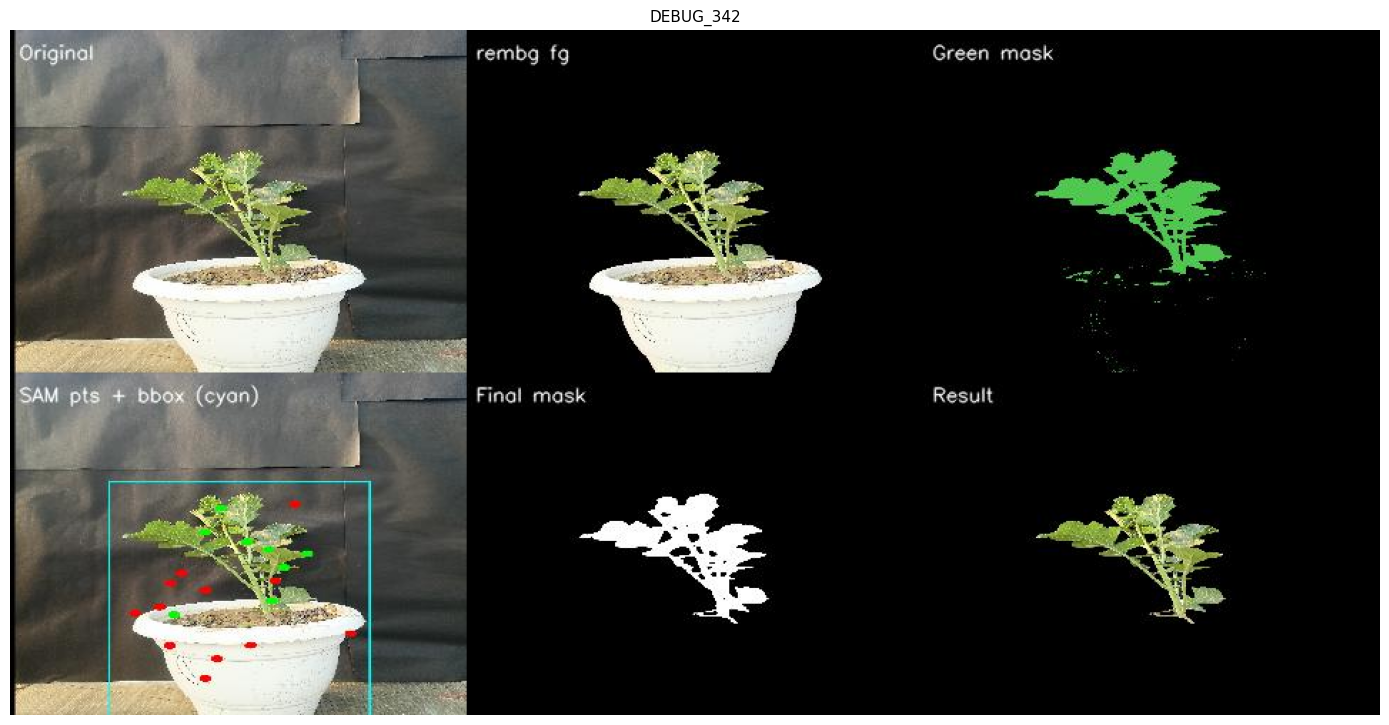

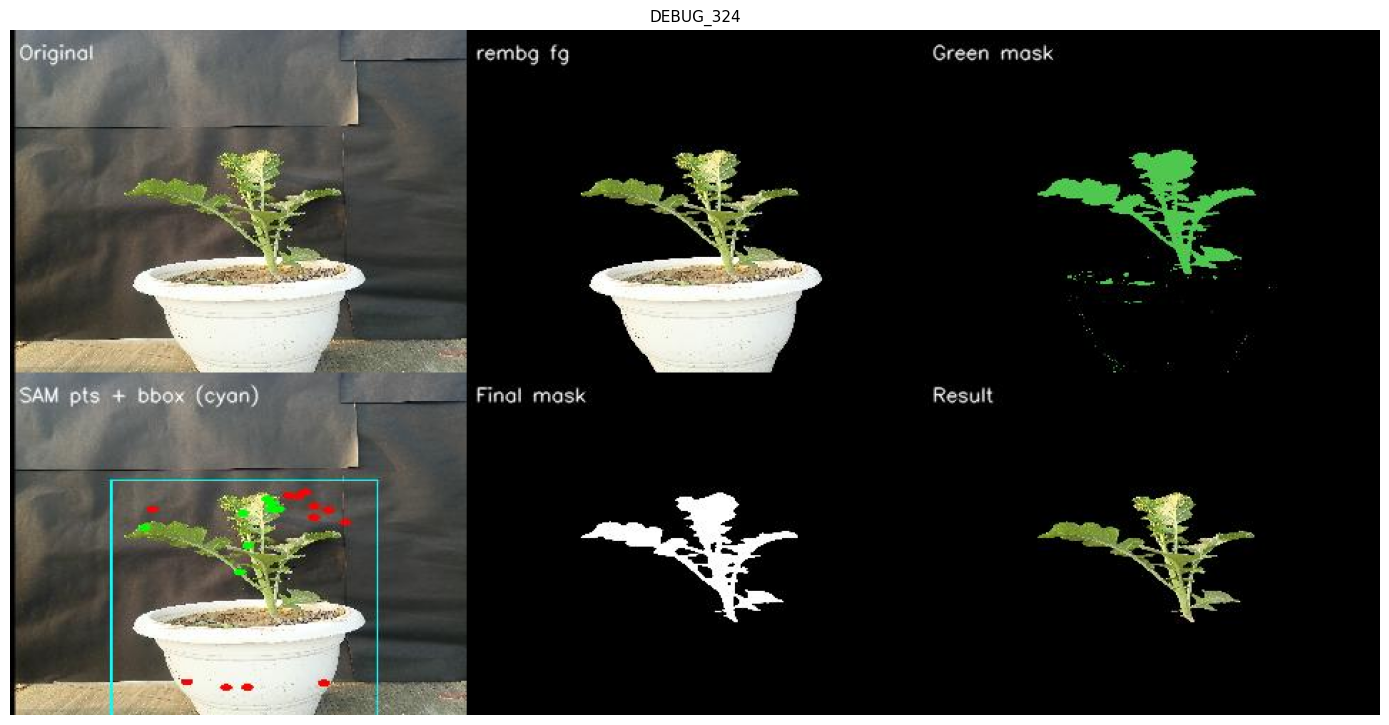

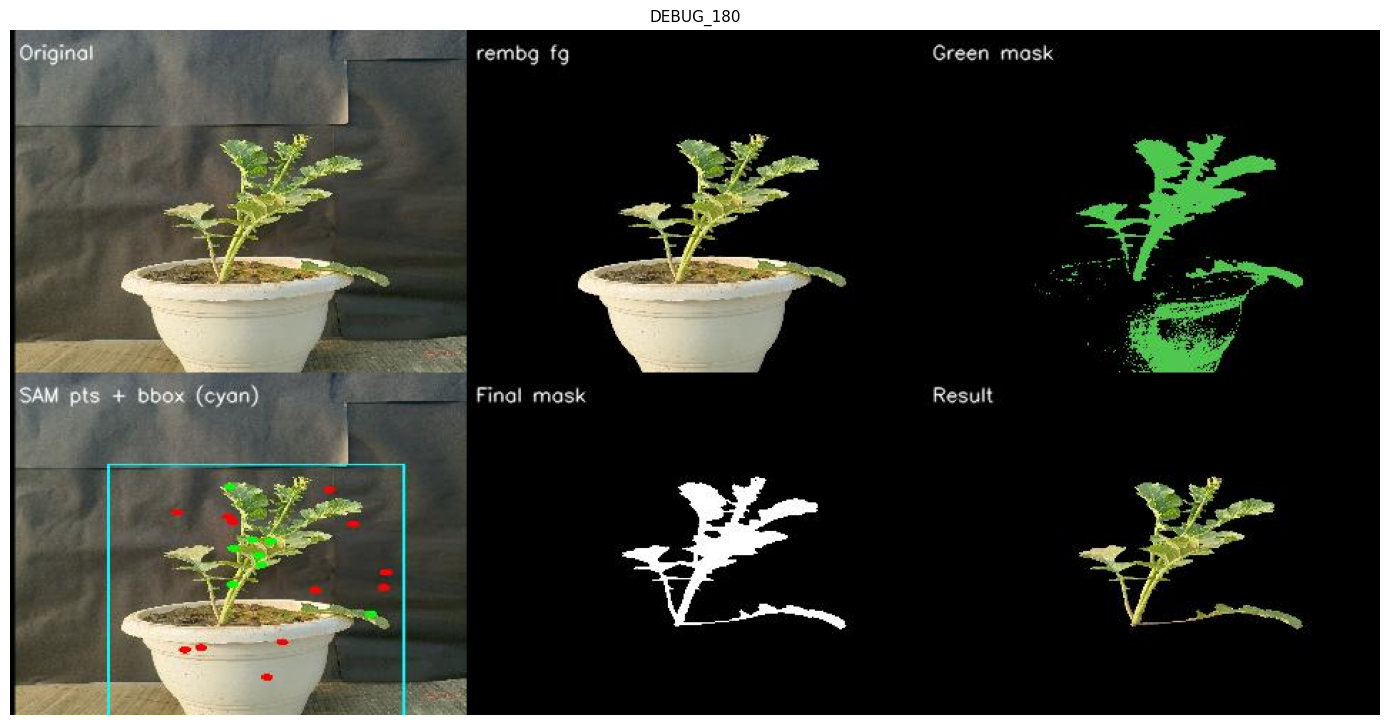

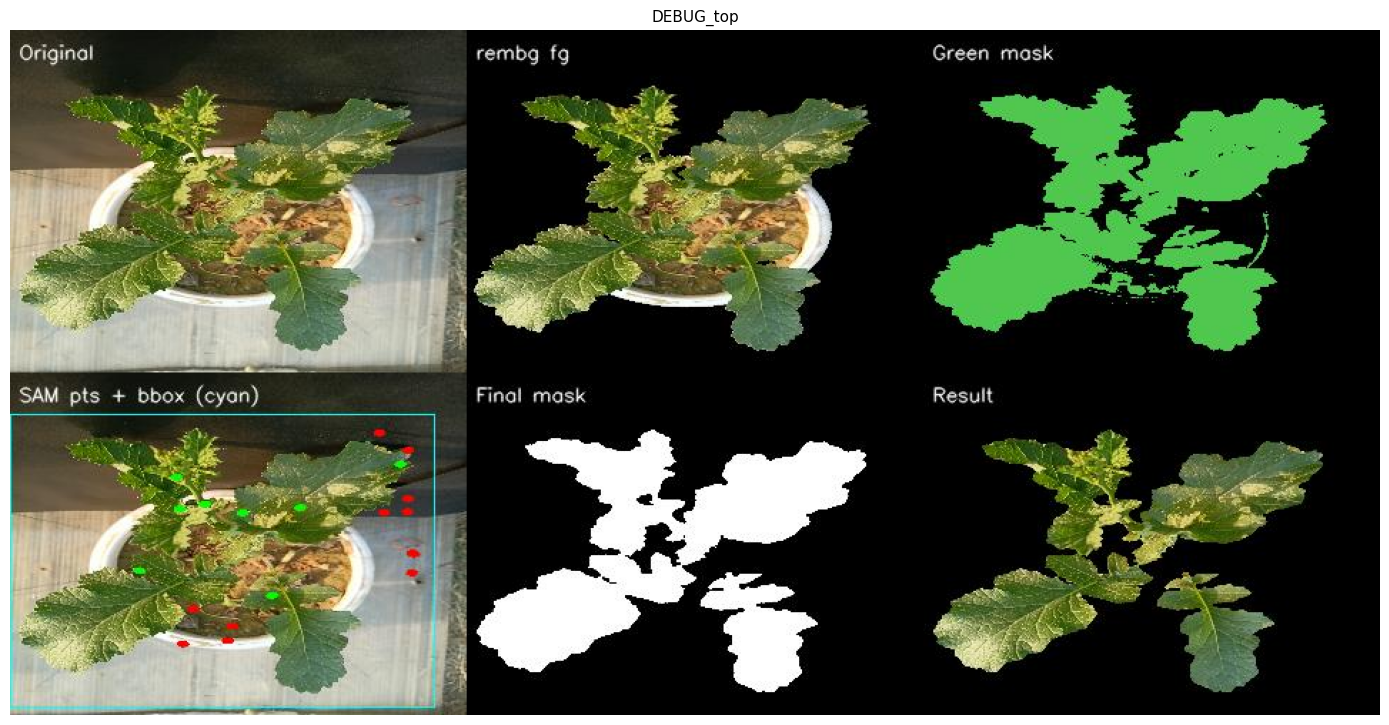

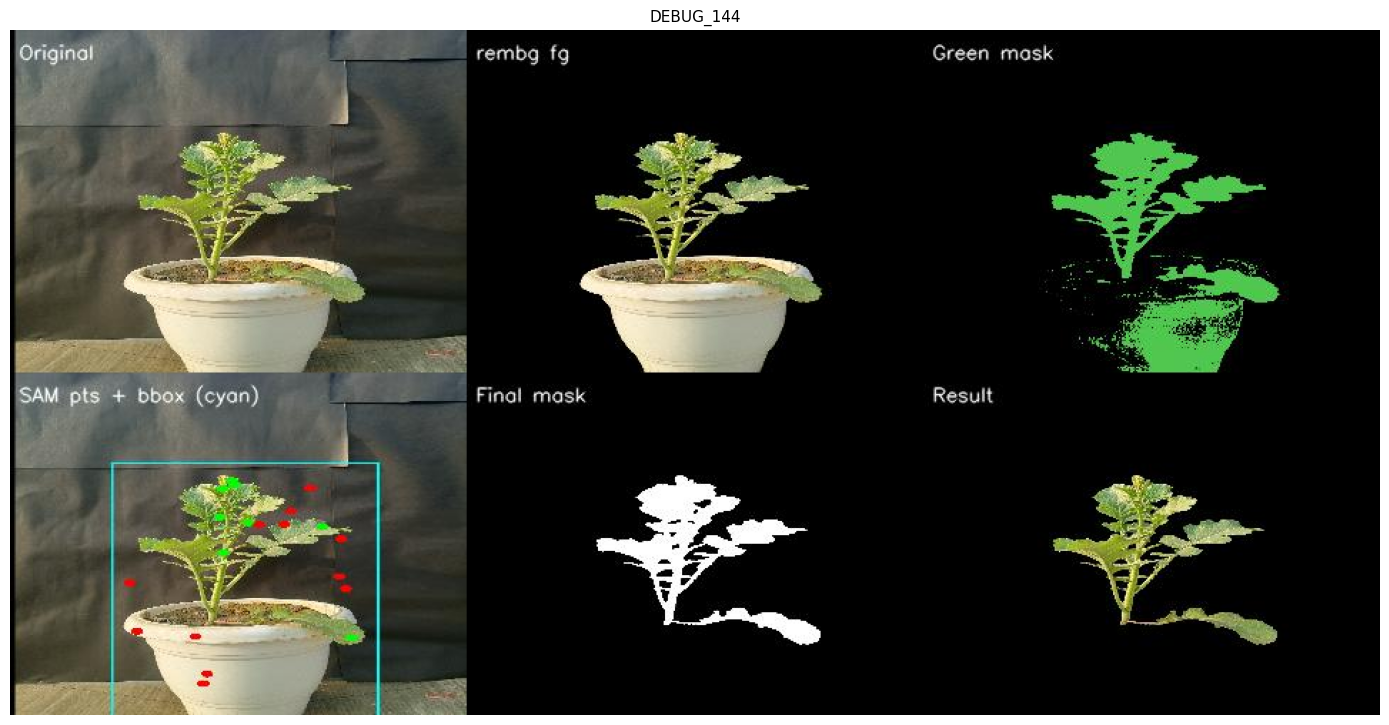

In [17]:
debug_files = sorted(Path(DEBUG_DIR).glob("DEBUG_*.jpg"))

if not debug_files:
    print("No debug mosaics found. Set SAVE_DEBUG = True and re-run.")
else:
    sample_dbg = random.sample(debug_files, min(5, len(debug_files)))
    for dbg in sample_dbg:
        img = np.array(Image.open(dbg))
        plt.figure(figsize=(14, 9))
        plt.imshow(img)
        plt.title(dbg.stem, fontsize=11)
        plt.axis("off")
        plt.tight_layout()
        plt.show()


In [18]:
print(f"\nResizing all {cfg.rotation.num_images} images to {cfg.camera.resized_w}x{cfg.camera.resized_h}...")
for image_name in views_key():
    fname = f'{image_name}.png'
    img   = cv2.imread(str(SEGMENTED_DIR / fname))
    if img is None: print(f'  Cannot read {fname}'); continue
    cv2.imwrite(str(RESIZED_DIR / fname),
                cv2.resize(img, (cfg.camera.resized_w, cfg.camera.resized_h), interpolation=cv2.INTER_AREA))
print('Resize done.')


Resizing all 20 images to 400x533...
Resize done.


<div style="width: 100%;">
  <h3><tt>Silhouette extraction</tt></h3>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
  <p><i>Using MEAN centroid across all views. Per-image centroid tracks leaf mass distribution which changes with rotation — causing over-correction and inconsistent views.Mean centroid cancels out leaf asymmetry and estimates the true turntable rotation axis.</i></p>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
</div>

Extracting silhouettes (simple threshold)...
                View    Plant px
----------------------------------
               0.png      10,273
             108.png      13,768
             126.png      14,400
             144.png      14,800
             162.png      13,430
              18.png      10,414
             180.png      11,818
             198.png      11,922
             216.png      12,080
             234.png      11,714
             252.png      11,398
             270.png      10,870
             288.png      10,157
             306.png       9,548
             324.png       9,900
             342.png      11,297
              36.png      10,691
              54.png      11,766
              72.png      12,683
              90.png      13,561

Done.


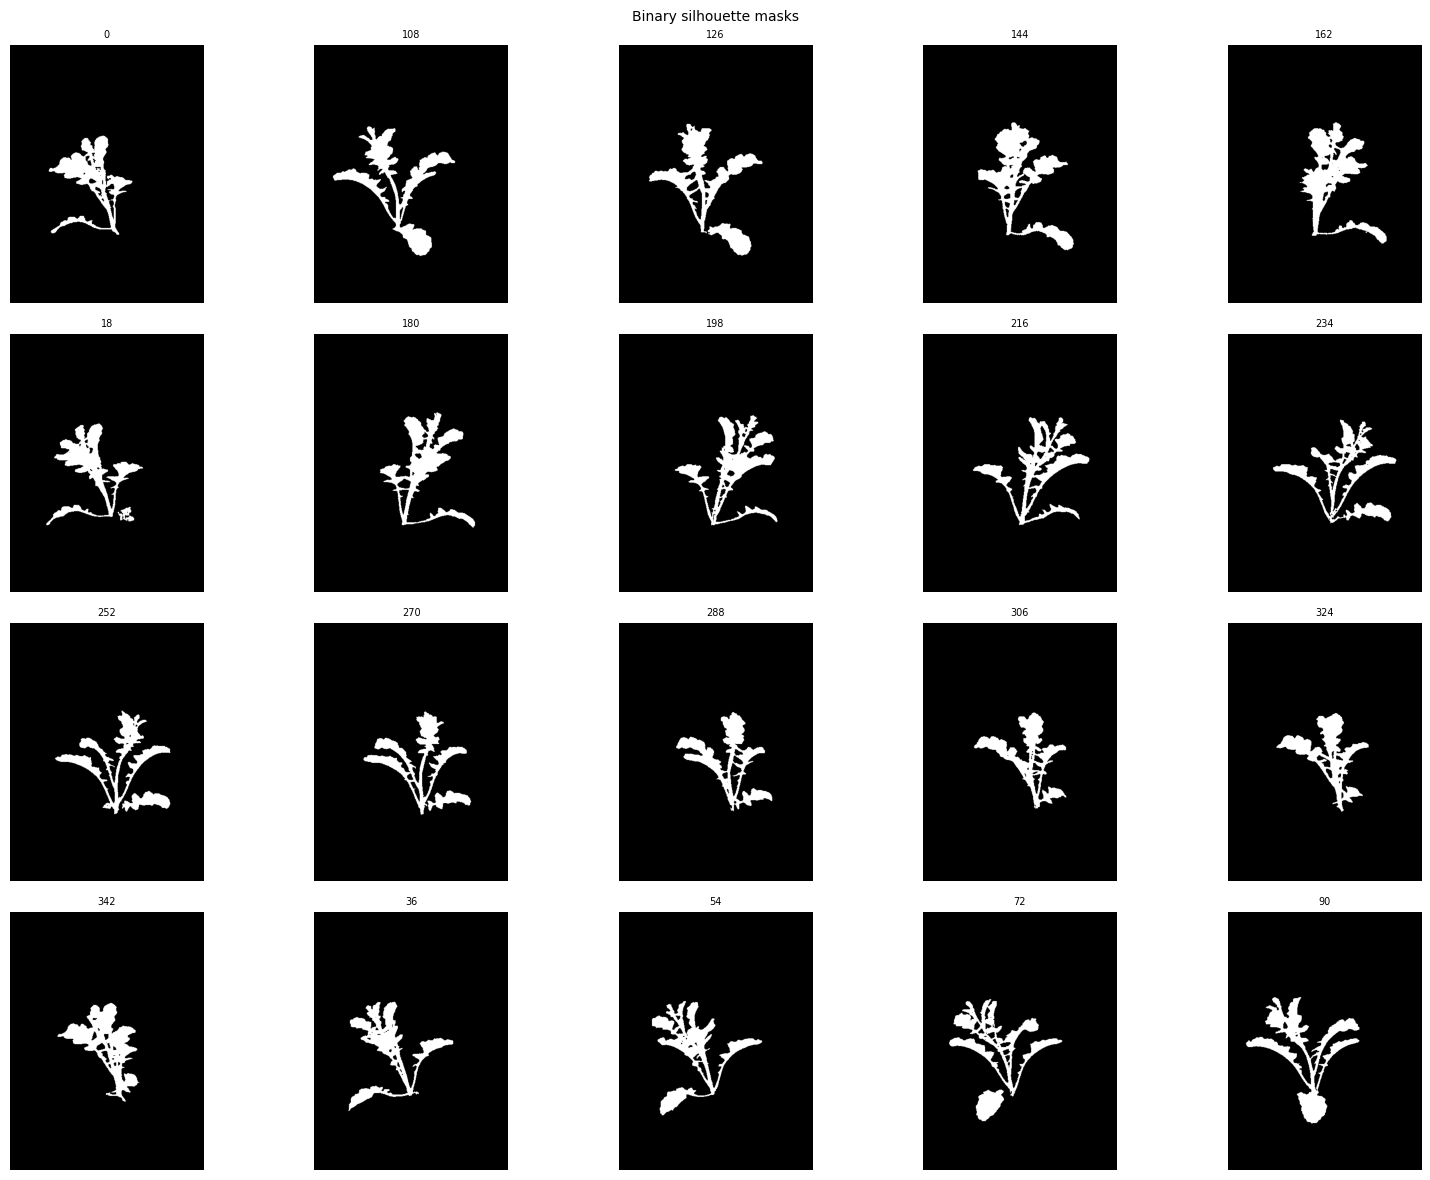

In [19]:
image_paths = sorted(RESIZED_DIR.glob("*.png"))

print('Extracting silhouettes (simple threshold)...')
print(f'{"View":>20}  {"Plant px":>10}')
print('-' * 34)

for path in image_paths:
    mask = extract_silhouette(image_path=path)

    fname = path.name

    # Save
    cv2.imwrite(str(MASK_DIR / fname), mask)

    # Overlay
    img_vis = cv2.imread(str(path))
    overlay = img_vis.copy()
    overlay[mask > 0] = (0, 200, 0)

    cv2.imwrite(
        str(MASK_VIS_DIR / fname),
        cv2.addWeighted(img_vis, 0.5, overlay, 0.5, 0)
    )

    plant_px = int((mask > 0).sum())
    print(f'{fname:>20}  {plant_px:>10,}')

print('\nDone.')

n_cols = 5
n_rows = math.ceil(len(image_paths) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

for idx, path in enumerate(image_paths):
    r, c = divmod(idx, n_cols)
    fname = path.name

    mask_raw = cv2.imread(str(MASK_DIR / fname), cv2.IMREAD_GRAYSCALE)
    axes[r][c].imshow(mask_raw, cmap='gray')
    axes[r][c].set_title(path.stem, fontsize=7)
    axes[r][c].axis('off')

for idx in range(len(image_paths), n_rows * n_cols):
    r, c = divmod(idx, n_cols)
    axes[r][c].axis('off')

plt.suptitle('Binary silhouette masks', fontsize=10)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'silhouettes_binary.png'), dpi=150)
plt.show()


<div style="width: 100%;">
  <h3><tt>Pseudo label generation using SAM</tt></h3>
  <!-- <hr style="border: 1px solid #ccc; width: 100%; margin: 0;"> -->
  <p><i></i></p>
  <!-- <hr style="border: 1px solid #ccc; width: 100%; margin: 0;"> -->
</div>

In [20]:
image_names = views_name()
print(image_names)

['0.png', '18.png', '36.png', '54.png', '72.png', '90.png', '108.png', '126.png', '144.png', '162.png', '180.png', '198.png', '216.png', '234.png', '252.png', '270.png', '288.png', '306.png', '324.png', '342.png']


In [21]:
print("Generating pseudo-labels...")
stats = run_pseudo_label_pipeline(
    image_names=image_names,
    resized_path=RESIZED_DIR,
    mask_path=MASK_DIR,
    label_path=LABEL_DIR,
    label_vis_path=LABEL_VIS_DIR,
    cfg=cfg,
    use_sam=True,
    predictor=predictor
    )


Generating pseudo-labels...

PSEUDO-LABEL GENERATION
  SAM:  Yes (point-prompted)



Pseudo-labels: 100%|██████████| 20/20 [00:54<00:00,  2.72s/it]


Done in 0.9 min

 view        bg     leaf    stem      pet    apex
--------------------------------------------------
 0.png   202,927    5,296     925    3,939     113
 18.png   202,786    5,253     734    4,314     113
 36.png   202,509    5,341     710    4,527     113
 54.png   201,434    6,004     746    4,903     113
 72.png   200,517    6,228      43    6,299     113
 90.png   199,639    7,660     103    5,685     113
 108.png   199,432    8,260     115    5,283     110
 126.png   198,800    8,832     106    5,350     112
 144.png   198,400    8,781     700    5,206     113
 162.png   199,770    7,794     736    4,787     113
 180.png   201,382    6,452     777    4,476     113
 198.png   201,278    5,669     719    5,421     113
 216.png   201,120    5,742     699    5,526     113
 234.png   201,486    5,478     757    5,366     113
 252.png   201,802    5,510       0    5,862      26
 270.png   202,330    5,575     507    4,675     113
 288.png   203,043    5,363     300    4

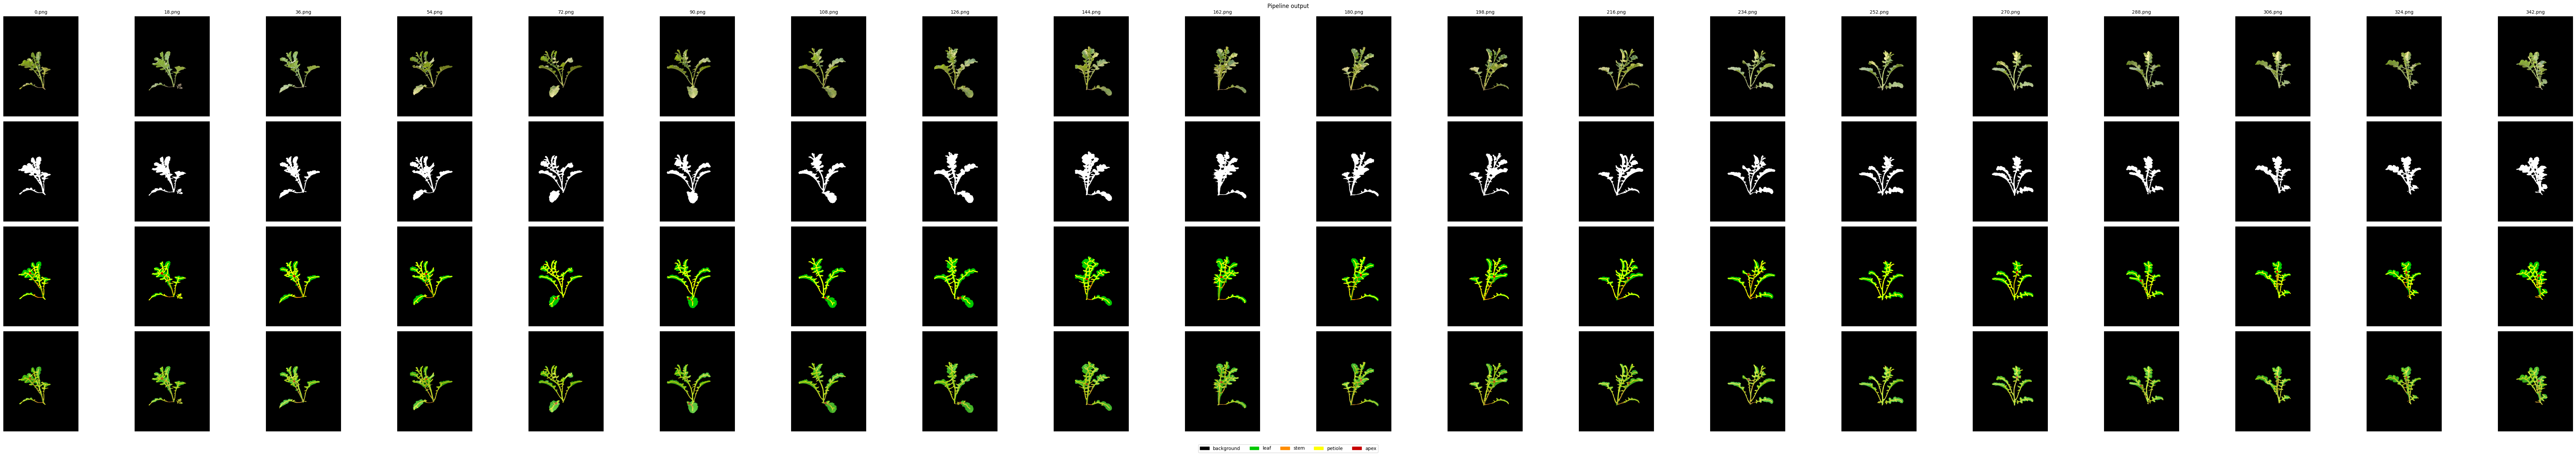

Saved → /content/plant_nerf/checkpoints/pipeline_output.png


In [22]:
visualize_pipeline_output(
    image_names=image_names,
    resized_path=RESIZED_DIR,
    mask_path=MASK_DIR,
    label_path=LABEL_DIR,
    checkpoint_path=CKPT_DIR,
    cfg=cfg,
    )

In [23]:
visualize_top_view(resized_path=RESIZED_DIR, mask_path=MASK_DIR, label_path=LABEL_DIR, checkpoint_path=CKPT_DIR, cfg=cfg)

Top image not found.


<div style="width: 100%;">
  <h3><tt>Camera poses for NeRF</tt></h3>
  <!-- <hr style="border: 1px solid #ccc; width: 100%; margin: 0;"> -->
  <p><i></i></p>
  <!-- <hr style="border: 1px solid #ccc; width: 100%; margin: 0;"> -->
</div>

In [24]:
plant_target = np.array([0,0,0])
poses = build_initial_poses(image_names=image_names, plant_target=plant_target, cfg=cfg)

In [25]:
def save_transforms_json(poses_dict, out_path):
    frames = []
    for image_name in image_names:
        view_key = image_name.split('.')[0]
        if view_key not in poses_dict:
            continue
        frames.append({
            'file_path': f'images_resized/{image_name}',
            'transform_matrix': poses_dict[view_key].tolist()
        })

    transform_data = {
                          'camera_model': 'OPENCV',
                          **cfg.camera.nerf_intrinsics,
                          'k1': 0.0, 'k2': 0.0, 'p1': 0.0, 'p2': 0.0,
                          'frames': frames
                      }

    with open(out_path, 'w') as f:
        json.dump(transform_data, f, indent=2)

print('Pose verification — plant_target projected position per view:')
print(f'  {"View":>8}  {"proj_x":>8}  {"proj_y":>8}  {"offset_from_centre":>20}')
for image_name in image_names:
    if image_name == 'top.png':
        continue

    rotation_angle = image_name.split('.')[0]

    P = poses[rotation_angle]
    R33 = P[:3, :3]
    t = P[:3, 3]
    cam_pos = plant_target - t
    cam_coord = R33.T @ cam_pos
    if cam_coord[2] != 0:
        px_proj = (-cam_coord[0] / cam_coord[2]) * cfg.camera.focal_length + cfg.camera.resized_w / 2
        py_proj = (-cam_coord[1] / cam_coord[2]) * cfg.camera.focal_length + cfg.camera.resized_h / 2
    else:
        px_proj = py_proj = cfg.camera.resized_w / 2
    off = math.hypot(px_proj - cfg.camera.resized_w/2, py_proj - cfg.camera.resized_h/2)
    print(f'  {str(rotation_angle):>8}  {px_proj:>8.1f}  {py_proj:>8.1f}  {off:>8.2f} px from centre')

save_transforms_json(poses, BASE_DIR / 'transforms.json')

print(f'\\nPoses done. focal={cfg.camera.focal_length:.1f}px')
print(f'Camera target: [{plant_target[0]:+.4f}, {plant_target[1]:+.4f}, {plant_target[2]:+.4f}]')
print(f'Top view enabled: {"yes" if "top.png" in image_names else "no"}')

Pose verification — plant_target projected position per view:
      View    proj_x    proj_y    offset_from_centre
         0     200.0     266.5      0.00 px from centre
        18     200.0     266.5      0.00 px from centre
        36     200.0     266.5      0.00 px from centre
        54     200.0     266.5      0.00 px from centre
        72     200.0     266.5      0.00 px from centre
        90     200.0     266.5      0.00 px from centre
       108     200.0     266.5      0.00 px from centre
       126     200.0     266.5      0.00 px from centre
       144     200.0     266.5      0.00 px from centre
       162     200.0     266.5      0.00 px from centre
       180     200.0     266.5      0.00 px from centre
       198     200.0     266.5      0.00 px from centre
       216     200.0     266.5      0.00 px from centre
       234     200.0     266.5      0.00 px from centre
       252     200.0     266.5      0.00 px from centre
       270     200.0     266.5      0.00 px f

<div style="width: 100%;">
  <h3><tt>Neural Radiance field Model</tt></h3>
</div>

In [26]:
n_params = sum(p.numel() for p in SemanticNeRF(plant_bound=cfg.plant_bound, num_classes=cfg.semantic.num_classes).parameters())
print(f'SemanticNeRF ready. Parameters: {n_params:,}')
print('Hash encoding bugs FIXED: abs() hash + precomputed corners + input clamp')

SemanticNeRF ready. Parameters: 33,631,177
Hash encoding bugs FIXED: abs() hash + precomputed corners + input clamp


In [27]:
print("Poses keys:", poses.keys())
print("Available view keys:", image_names)

Poses keys: dict_keys(['0', '18', '36', '54', '72', '90', '108', '126', '144', '162', '180', '198', '216', '234', '252', '270', '288', '306', '324', '342'])
Available view keys: ['0.png', '18.png', '36.png', '54.png', '72.png', '90.png', '108.png', '126.png', '144.png', '162.png', '180.png', '198.png', '216.png', '234.png', '252.png', '270.png', '288.png', '306.png', '324.png', '342.png']


In [28]:
dataset = PlantDataset(image_names=image_names, poses=poses, label_path=LABEL_DIR, mask_path=MASK_DIR, resized_path=RESIZED_DIR, cfg=cfg)

print(f'Phase 1 Dataset ready  ({len(image_names)} side views only).')
print(f'  Rays/batch    : {cfg.training.batch_rays:,}')
if 'top.png' in image_names:
    print(f'  Top view will be introduced at step {cfg.loss.top_view_start_iter}')
else:
    print('  ⚠️  No top view found — running side-views-only pipeline')

Loading dataset (20 views)...


100%|██████████| 20/20 [00:00<00:00, 35.90it/s]


  Total rays :    4,264,000
  Plant rays :      236,490  (5.5%)
  BG rays    :    4,027,510  (94.5%)
  Sampling   : 75% plant / 25% background per batch
Phase 1 Dataset ready  (20 side views only).
  Rays/batch    : 4,096
  ⚠️  No top view found — running side-views-only pipeline


<div style="width: 100%;">
  <h3><tt>Training</tt></h3>
</div>

In [29]:
vars_to_delete = ['session', 'predictor', 'img', 'hsv', 'rough', 'P', 'cam_coord']

for var_name in vars_to_delete:
    if var_name in globals():
        del globals()[var_name]
        print(f"Deleted: {var_name}")

gc.collect()
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print('═' * 40)
print("Memory Sweep Complete. Current VRAM:")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
print('═' * 40)

Deleted: session
Deleted: predictor
Deleted: img
Deleted: P
Deleted: cam_coord
════════════════════════════════════════
Memory Sweep Complete. Current VRAM:
Allocated: 0.01 GB
Reserved:  0.02 GB
════════════════════════════════════════


In [30]:
early_stop_config = EarlyStopConfig()
early_stopper     = EarlyStopper(early_stop_config)

view_keys = [k.split('.')[0] for k in image_names]

model        = SemanticNeRF(plant_bound=cfg.plant_bound, num_classes=cfg.semantic.num_classes).to(cfg.device)
model        = torch.compile(model)
pose_refiner = PoseRefiner(base_poses=poses, views=view_keys).to(cfg.device)

optimizer = torch.optim.Adam([
    {'params': model.parameters(),        'lr': cfg.training.lr},
    {'params': pose_refiner.parameters(), 'lr': cfg.training.pose_lr},
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.training.num_iters, eta_min=cfg.training.lr * 0.01)
scaler = torch.amp.GradScaler('cuda', enabled=cfg.training.use_amp)

history = {k: [] for k in
           ['total', 'color', 'silhouette', 'semantic',
            'distortion', 'bg_acc', 'pose', 'top_pose']}   # top_pose added
early_stopped        = False
stop_condition_met_at = None

step    = 0
pbar    = tqdm(total=cfg.training.num_iters, desc='Training')

while step < cfg.training.num_iters:
    # INTRODCUTION OF TOP VIEW
    if step == cfg.training.top_view_start_iter and cfg.rotation.use_top_view:

        print(f'\n{"═"*60}')
        print(f'Step {step}: PHASE 2 — Top view introduced + top-view pose refinement ON')
        print(f'{"═"*60}')

        dataset = PlantDataset(view_keys=view_keys)
        print(f'  Dataset rebuilt: {len(view_keys)} views (side + top)')


    rays_o_base, rays_d_base, view_ids, gt_rgb, gt_mask, gt_sem = dataset.get_batch(
        cfg.training.batch_rays,
        device=cfg.device
    )
    bg_mask = (gt_mask.squeeze() < 0.5)

    model.update_step(step)

    if step >= cfg.training.pose_start_iter:
        rays_o, rays_d = pose_refiner.transform_rays(
            rays_o_base, rays_d_base, view_ids)

    elif step >= cfg.training.top_view_start_iter and pose_refiner.top_view_exists:
        top_global_id = pose_refiner.key_to_idx['top']
        is_top_ray    = (view_ids == top_global_id)
        if is_top_ray.any():
            rays_o = rays_o_base.clone()
            rays_d = rays_d_base.clone()
            top_ro, top_rd = pose_refiner.transform_rays(
                rays_o_base[is_top_ray],
                rays_d_base[is_top_ray],
                view_ids[is_top_ray],
            )
            rays_o[is_top_ray] = top_ro
            rays_d[is_top_ray] = top_rd
        else:
            rays_o, rays_d = rays_o_base, rays_d_base

    else:
        rays_o, rays_d = rays_o_base, rays_d_base

    with torch.amp.autocast('cuda', enabled=cfg.training.use_amp):
        pts_c, z_c = sample_coarse(
            rays_o, rays_d, cfg.training.near, cfg.training.far,
            cfg.training.n_samples_coarse)
        N, S, _ = pts_c.shape
        dc, cc, sc = model(
            pts_c.reshape(-1, 3),
            rays_d.unsqueeze(1).expand(N, S, 3).reshape(-1, 3))
        rgb_c, acc_c, sem_c, _, wc = volume_render(
            dc.reshape(N, S, 1), cc.reshape(N, S, 3),
            sc.reshape(N, S, cfg.semantic.num_classes), z_c, rays_d)

        pts_f, z_f = sample_fine(rays_o, rays_d, z_c, wc.detach(),
                                 cfg.training.n_samples_fine)
        N, S2, _ = pts_f.shape
        df, cf, sf = model(
            pts_f.reshape(-1, 3),
            rays_d.unsqueeze(1).expand(N, S2, 3).reshape(-1, 3))
        rgb_f, acc_f, sem_f, _, wf = volume_render(
            df.reshape(N, S2, 1), cf.reshape(N, S2, 3),
            sf.reshape(N, S2, cfg.semantic.num_classes), z_f, rays_d)

        preds = {'rgb_f': rgb_f, 'rgb_c': rgb_c,
                 'acc_f': acc_f, 'acc_c': acc_c,
                 'sem_f': sem_f, 'sem_c': sem_c,
                 'wf': wf, 'z_f': z_f, 'wc': wc, 'z_c': z_c}
        gts_d = {'rgb': gt_rgb, 'mask': gt_mask, 'sem': gt_sem}

        loss, loss_log = compute_total_loss(preds, gts_d, step, cfg, pose_refiner)

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)

    if step >= cfg.training.top_view_start_iter and pose_refiner.top_view_exists:
        torch.nn.utils.clip_grad_norm_(pose_refiner.parameters(), max_norm=0.1)
    elif step >= cfg.training.pose_start_iter:
        torch.nn.utils.clip_grad_norm_(pose_refiner.parameters(), max_norm=0.1)

    scaler.step(optimizer)
    scaler.update()
    scheduler.step()

    for k in history.keys():
        history[k].append(loss_log.get(k, 0.0))

    if step % cfg.training.log_every == 0:
        with torch.no_grad():
            plant_acc_log = acc_f[~bg_mask].mean().item() if (~bg_mask).any() else 0.0
            bg_acc_log    = acc_f[ bg_mask].mean().item() if   bg_mask.any() else 0.0
            psnr_log      = -10 * math.log10(F.mse_loss(rgb_f, gt_rgb).item() + 1e-8)

        print(
            f'Step {step:5d}: loss={loss_log["total"]:.4f} | '
            f'color={loss_log["color"]:.4f}  sil={loss_log["silhouette"]:.4f}  '
            f'sem={loss_log["semantic_w"]:.4f}  dist={loss_log["distortion"]:.4f}  '
            f'bg_acc={bg_acc_log:.3f}  plant_acc={plant_acc_log:.3f}  '
            f'psnr={psnr_log:.1f}dB  '
            f'pose={loss_log["pose_w"]:.5f}  '
            f'top_pose={loss_log["top_pose_w"]:.5f}'    # NEW
        )

        with torch.no_grad():
            max_rot   = pose_refiner.delta_rot.abs().max().item()
            max_trans = pose_refiner.delta_trans.abs().max().item()
            print(f'         > Camera Delta: Rot_max={max_rot:.6f} rad | Trans_max={max_trans:.6f} units')

        if step >= early_stop_config.min_iters:
            with torch.no_grad():
                plant_acc_est = acc_f[~bg_mask].mean().item() if (~bg_mask).any() else 0.0
                bg_acc_est    = acc_f[ bg_mask].mean().item() if   bg_mask.any() else 1.0
                psnr_est      = -10 * math.log10(F.mse_loss(rgb_f, gt_rgb).item() + 1e-8)

            if early_stopper.step(step, plant_acc_est, bg_acc_est, psnr_est):
                print(f'\nEarly stopping triggered at step {step}')
                break

    step += 1
    pbar.update(1)

pbar.close()

Training:   0%|          | 1/10000 [01:32<256:14:22, 92.26s/it]

Step     0: loss=9.5575 | color=0.2327  sil=4.7365  sem=0.0000  dist=0.0026  bg_acc=0.049  plant_acc=0.045  psnr=6.7dB  pose=0.00000  top_pose=0.00000
         > Camera Delta: Rot_max=0.000003 rad | Trans_max=0.000003 units


Training:   2%|▏         | 201/10000 [02:25<40:11,  4.06it/s]

Step   200: loss=2.3050 | color=0.0491  sil=0.9859  sem=0.0000  dist=0.3184  bg_acc=0.237  plant_acc=0.794  psnr=13.5dB  pose=0.00000  top_pose=0.00000
         > Camera Delta: Rot_max=0.000003 rad | Trans_max=0.000003 units


Training:   4%|▍         | 401/10000 [03:14<42:07,  3.80it/s]

...

Training:  96%|█████████▌| 9601/10000 [45:45<01:56,  3.42it/s]

Step  9600: loss=0.8595 | color=0.0259  sil=0.4314  sem=0.3619  dist=0.1307  bg_acc=0.083  plant_acc=0.910  psnr=16.3dB  pose=0.00002  top_pose=0.00000
         > Camera Delta: Rot_max=0.055880 rad | Trans_max=0.110018 units


Training:  98%|█████████▊| 9801/10000 [46:43<00:58,  3.41it/s]

Step  9800: loss=0.8302 | color=0.0261  sil=0.3975  sem=0.3654  dist=0.1317  bg_acc=0.078  plant_acc=0.907  psnr=16.3dB  pose=0.00002  top_pose=0.00000
         > Camera Delta: Rot_max=0.055979 rad | Trans_max=0.109952 units


Training: 100%|██████████| 10000/10000 [47:40<00:00,  3.50it/s]


In [31]:
poses = pose_refiner.export_pose_dict()
save_transforms_json(poses, BASE_DIR / 'transforms.json')

view_keys = [k.split('.')[0] for k in image_names]

with torch.no_grad():
    print('\nPose deltas after training:')
    for view_key in view_keys:
        idx = pose_refiner.key_to_idx[view_key]
        rot_deg = torch.linalg.norm(pose_refiner.delta_rot[idx]).item() * 180.0 / math.pi
        trans_mag = torch.linalg.norm(pose_refiner.delta_trans[idx]).item()
        print(f'  {str(view_key):>8}: rot≈{rot_deg:6.2f}°  trans≈{trans_mag:7.4f}')


Pose deltas after training:
         0: rot≈  0.58°  trans≈ 0.0102
        18: rot≈  1.04°  trans≈ 0.0389
        36: rot≈  0.90°  trans≈ 0.0105
        54: rot≈  1.20°  trans≈ 0.0183
        72: rot≈  1.67°  trans≈ 0.0270
        90: rot≈  0.54°  trans≈ 0.0167
       108: rot≈  0.45°  trans≈ 0.0203
       126: rot≈  0.84°  trans≈ 0.0188
       144: rot≈  0.32°  trans≈ 0.0062
       162: rot≈  0.04°  trans≈ 0.0028
       180: rot≈  0.02°  trans≈ 0.0004
       198: rot≈  0.33°  trans≈ 0.0040
       216: rot≈  0.44°  trans≈ 0.0078
       234: rot≈  0.42°  trans≈ 0.0097
       252: rot≈  1.75°  trans≈ 0.0047
       270: rot≈  3.13°  trans≈ 0.0179
       288: rot≈  3.24°  trans≈ 0.0645
       306: rot≈  2.20°  trans≈ 0.0363
       324: rot≈  1.38°  trans≈ 0.1106
       342: rot≈  1.63°  trans≈ 0.0107


<div style="width: 100%;">
  <h3><tt>Rendering the results</tt></h3>
</div>

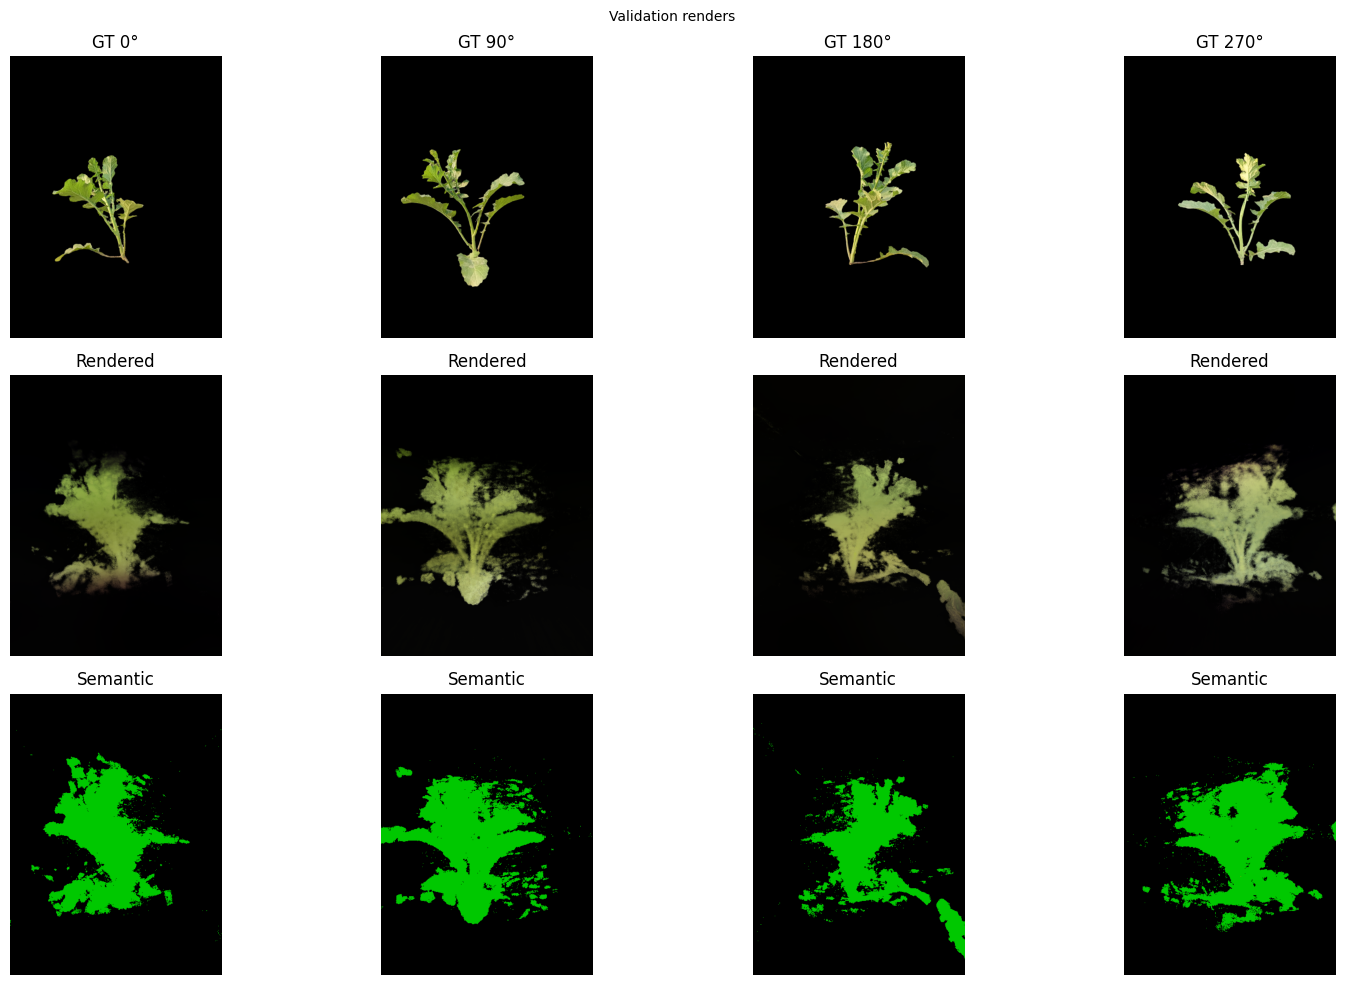

In [36]:
from src.models.arch import get_rays
model.eval()

def render_image(model, pose, H, W, focal, chunk=1024):
    pose_t=torch.tensor(pose,dtype=torch.float32,device=cfg.device)
    ro,rd=get_rays(H,W,focal,pose_t)
    ro_f=ro.reshape(-1,3); rd_f=rd.reshape(-1,3); N=ro_f.shape[0]
    rgbs,accs,sems=[],[],[]
    with torch.no_grad():
        for s in range(0,N,chunk):
            e=min(s+chunk,N); r_o=ro_f[s:e]; r_d=rd_f[s:e]
            pts_c,z_c=sample_coarse(r_o,r_d,cfg.training.near,cfg.training.far,cfg.training.n_samples_coarse)
            n,sc,_=pts_c.shape
            dc,cc,sc2=model(pts_c.reshape(-1,3),r_d.unsqueeze(1).expand(n,sc,3).reshape(-1,3))
            dc=dc.reshape(n,sc,1);cc=cc.reshape(n,sc,3);sc2=sc2.reshape(n,sc,cfg.semantic.num_classes)
            _,_,_,_,wc=volume_render(dc,cc,sc2,z_c,r_d)
            pts_f,z_f=sample_fine(r_o,r_d,z_c,wc,cfg.training.n_samples_fine)
            n,sf,_=pts_f.shape
            df,cf,sf2=model(pts_f.reshape(-1,3),r_d.unsqueeze(1).expand(n,sf,3).reshape(-1,3))
            df=df.reshape(n,sf,1);cf=cf.reshape(n,sf,3);sf2=sf2.reshape(n,sf,cfg.semantic.num_classes)
            rgb,acc,sem,_,_=volume_render(df,cf,sf2,z_f,r_d)
            rgbs.append(rgb.cpu());accs.append(acc.cpu());sems.append(sem.cpu())
    rgb_img=torch.cat(rgbs).reshape(H,W,3).numpy()
    sem_cls=torch.cat(sems).reshape(H,W,cfg.semantic.num_classes).argmax(-1).numpy().astype(np.uint8)
    return rgb_img, sem_cls

# Render 4 test views
fig,axes=plt.subplots(3,4,figsize=(16,10))
for col,angle in enumerate([0,90,180,270]):
    fname=f'{angle}.png'
    gt=cv2.cvtColor(cv2.imread(str(RESIZED_DIR/fname)),cv2.COLOR_BGR2RGB)
    rgb_p,sem_p=render_image(model,poses[str(angle)],cfg.camera.resized_h,cfg.camera.resized_w,cfg.camera.focal_length)
    sem_c=np.zeros((*sem_p.shape,3),dtype=np.uint8)
    for cid,bgr in cfg.semantic.class_colors_bgr.items(): sem_c[sem_p==cid]=bgr[::-1]
    axes[0][col].imshow(gt);              axes[0][col].set_title(f'GT {angle}°')
    axes[1][col].imshow(rgb_p.clip(0,1)); axes[1][col].set_title('Rendered')
    axes[2][col].imshow(sem_c);           axes[2][col].set_title('Semantic')
    for r in range(3): axes[r][col].axis('off')
plt.suptitle('Validation renders',fontsize=10)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/'validation_renders.png'),dpi=150)
plt.show()

In [38]:
# PSNR all views
psnrs=[]
for angle in cfg.rotation.rotation_angles:
    gt=cv2.cvtColor(cv2.imread(str(RESIZED_DIR/f'{angle}.png')),
                    cv2.COLOR_BGR2RGB).astype(np.float32)/255.
    rgb_p,_=render_image(model,poses[str(angle)],cfg.camera.resized_h,cfg.camera.resized_w,cfg.camera.focal_length)
    psnr=-10*np.log10(np.mean((gt-rgb_p.clip(0,1))**2)+1e-8)
    psnrs.append(psnr)
    print(f'  {angle:3d}°  PSNR={psnr:.2f} dB')
print(f'\nMean PSNR: {np.mean(psnrs):.2f} dB')

    0°  PSNR=19.77 dB
   18°  PSNR=18.97 dB
   36°  PSNR=17.30 dB
   54°  PSNR=17.16 dB
   72°  PSNR=17.47 dB
   90°  PSNR=18.01 dB
  108°  PSNR=18.12 dB
  126°  PSNR=18.44 dB
  144°  PSNR=19.09 dB
  162°  PSNR=19.21 dB
  180°  PSNR=19.19 dB
  198°  PSNR=19.62 dB
  216°  PSNR=18.99 dB
  234°  PSNR=17.54 dB
  252°  PSNR=16.80 dB
  270°  PSNR=16.24 dB
  288°  PSNR=16.84 dB
  306°  PSNR=17.43 dB
  324°  PSNR=17.49 dB
  342°  PSNR=19.17 dB

Mean PSNR: 18.14 dB


<div style="width: 100%;">
  <h3><tt>Novel view synthesis</tt></h3>
</div>

In [40]:
from src.models.poses import look_at

def orbit_pose(angle_deg, target=np.zeros(3, dtype=np.float32), radius=None):
    if radius is None:
        radius = cfg.camera.camera_radius

    ar = math.radians(angle_deg)

    eye = target + np.array([
        radius * math.sin(ar),
        0.0,
        radius * math.cos(ar)
    ], dtype=np.float32)

    return look_at(eye, target=target)

pose_novel = orbit_pose(45.0)

rgb_novel, sem_novel = render_image(
    model,
    pose_novel,
    cfg.camera.resized_h,
    cfg.camera.resized_w,
    cfg.camera.focal_length
)

<div style="width: 100%;">
  <h3><tt>Mesh Extraction</tt></h3>
</div>

In [ ]:
# 1. Note the QUOTES! We are passing strings.
# Add any other large variables you used during training here (like 'optimizer', 'loss', etc.)
vars_to_delete = ['session', 'predictor', 'img', 'hsv', 'rough', 'P', 'cam_coord']

for var_name in vars_to_delete:
    if var_name in globals():
        del globals()[var_name]
        print(f"Deleted: {var_name}")

# 2. Aggressive Garbage Collection
gc.collect()
gc.collect()

# 3. Empty the PyTorch Cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect() # Clears out inter-process communication memory

# 4. Prove it worked!
print('═' * 40)
print("Memory Sweep Complete. Current VRAM:")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
print('═' * 40)

In [ ]:
print('Querying density on 3D voxel grid...')
xs=torch.linspace(-cfg.plant_bound,cfg.plant_bound,cfg.grid_res)
gx,gy,gz=torch.meshgrid(xs,xs,xs,indexing='ij')
pts_flat=torch.stack([gx,gy,gz],-1).reshape(-1,3)
density_vol=np.zeros(cfg.grid_res**3,dtype=np.float32)
sem_vol    =np.zeros(cfg.grid_res**3,dtype=np.uint8)
CHUNK=8192
model.eval()
with torch.no_grad():
    for s in tqdm(range(0,pts_flat.shape[0],CHUNK),desc='Density query'):
        e=min(s+CHUNK,pts_flat.shape[0])
        p=pts_flat[s:e].to(cfg.device); dummy=torch.zeros_like(p)
        den,_,sem=model(p,dummy)
        density_vol[s:e]=den.squeeze(-1).cpu().numpy()
        sem_vol[s:e]=sem.argmax(-1).cpu().numpy().astype(np.uint8)
density_vol=density_vol.reshape(cfg.grid_res,cfg.grid_res,cfg.grid_res)
sem_vol    =sem_vol    .reshape(cfg.grid_res,cfg.grid_res,cfg.grid_res)

del pts_flat, gx, gy, gz, xs
gc.collect()

print(f'Density: min={density_vol.min():.2f} max={density_vol.max():.2f}')

verts,faces,normals,_=measure.marching_cubes(
    density_vol, level=cfg.density_threshold, spacing=(2*cfg.plant_bound/cfg.grid_res,)*3)
verts -= cfg.plant_bound
print(f'Mesh: {len(verts):,} vertices, {len(faces):,} faces')

def w2v(v,b,r): return ((v+b)/(2*b)*(r-1)).clip(0,r-1).astype(int)
vi=w2v(verts[:,0],cfg.plant_bound,cfg.grid_res)
vj=w2v(verts[:,1],cfg.plant_bound,cfg.grid_res)
vk=w2v(verts[:,2],cfg.plant_bound,cfg.grid_res)
vc=sem_vol[vi,vj,vk]
vcol=np.zeros((len(verts),3),dtype=np.float32)
for cid,bgr in cfg.semantic.class_colors_bgr.items():
    vcol[vc==cid]=np.array(bgr[::-1],np.float32)/255.

del density_vol, sem_vol, vi, vj, vk, vc
gc.collect()

obj_path=OUTPUT_DIR/'plant_3d.obj'
with open(obj_path,'w') as f:
    f.write('# Semantic NeRF Plant\n')
    for v,c in zip(verts,vcol): f.write(f'v {v[0]:.6f} {v[1]:.6f} {v[2]:.6f} {c[0]:.4f} {c[1]:.4f} {c[2]:.4f}\n')
    f.write('\n')
    for face in faces: f.write(f'f {face[0]+1} {face[1]+1} {face[2]+1}\n')
print(f'Saved: {obj_path}')

try:
    import open3d as o3d

    print('\nBuilding raw Open3D mesh...')
    o3d_mesh = o3d.geometry.TriangleMesh()
    o3d_mesh.vertices = o3d.utility.Vector3dVector(verts)
    o3d_mesh.triangles = o3d.utility.Vector3iVector(faces)
    o3d_mesh.vertex_colors = o3d.utility.Vector3dVector(vcol)

    del verts, faces, vcol
    gc.collect()

    print('Filtering out floating noise (keeping largest connected component)...')
    triangle_clusters, cluster_n_triangles, cluster_area = o3d_mesh.cluster_connected_triangles()

    triangle_clusters = np.asarray(triangle_clusters)
    cluster_n_triangles = np.asarray(cluster_n_triangles)
    largest_cluster_idx = cluster_n_triangles.argmax()

    triangles_to_remove = triangle_clusters != largest_cluster_idx
    o3d_mesh.remove_triangles_by_mask(triangles_to_remove)
    o3d_mesh.remove_unreferenced_vertices()

    print(f'Cleaned Mesh: {len(o3d_mesh.vertices):,} vertices, {len(o3d_mesh.triangles):,} faces')

    print('Applying Laplacian smoothing...')
    o3d_mesh = o3d_mesh.filter_smooth_laplacian(number_of_iterations=10, lambda_filter=0.5)

    ply_path = str(OUTPUT_DIR / 'plant_3d_clean.ply')
    o3d.io.write_triangle_mesh(ply_path, o3d_mesh)
    print(f'✅ Saved cleaned & smoothed PLY to: {ply_path}')
except Exception as e:
    print(f'Open3D processing failed: {e}. Raw OBJ is still saved.')

<div style="width: 100%;">
  <h3><tt>Mesh Preview</tt></h3>
</div>

In [ ]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
fig=plt.figure(figsize=(12,5))
for idx,(elev,azim) in enumerate([(30,30),(30,120),(30,210)]):
    ax=fig.add_subplot(1,3,idx+1,projection='3d')
    stride=max(1,len(faces)//3000)
    fs=faces[::stride][:3000]
    poly=Poly3DCollection([verts[f] for f in fs],alpha=0.6)
    poly.set_facecolor([[*vcol[f[0]],0.7] for f in fs])
    ax.add_collection3d(poly)
    ax.set_xlim(verts[:,0].min(),verts[:,0].max())
    ax.set_ylim(verts[:,1].min(),verts[:,1].max())
    ax.set_zlim(verts[:,2].min(),verts[:,2].max())
    ax.view_init(elev=elev,azim=azim)
    ax.set_title(f'View {idx+1}',fontsize=9)
handles=[mpatches.Patch(color=np.array(CLASS_COLORS_BGR[c][::-1])/255,label=CLASS_NAMES[c]) for c in CLASS_NAMES]
fig.legend(handles=handles,loc='lower center',ncol=5,fontsize=9)
plt.suptitle('3D Reconstruction — color = semantic class',fontsize=11)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/'mesh_preview.png'),dpi=150)
plt.show()

<div style="width: 100%;">
  <h3><tt>Post processing</tt></h3>
</div>

In [ ]:
import open3d as o3d
import numpy as np
from scipy.spatial import ConvexHull, cKDTree

class EnhancedGeometricPhenotyper:
    def __init__(self, filepath):
        self.filepath = filepath
        self.pcd = None
        self.stem_pcd = None
        self.leaf_pcd = None
        self.leaf_clusters = []
        np.random.seed(42) # For consistent sampling across runs

    def run_pipeline(self):
        print("[1/4] Loading and Sampling Point Cloud...")
        mesh = o3d.io.read_triangle_mesh(self.filepath)
        self.pcd = mesh.sample_points_uniformly(number_of_points=200000)

        print("[2/4] Segmenting Stem and Leaves...")
        points = np.asarray(self.pcd.points)

        # Robust Center: Median is less sensitive to leaning canopies than Mean
        center_xy = np.median(points[:, :2], axis=0)
        dist_from_center = np.linalg.norm(points[:, :2] - center_xy, axis=1)
        z_min, z_max = np.min(points[:, 2]), np.max(points[:, 2])

        # Stem = inner 6% of the plant's radial width, plus the very bottom base
        is_stem = (dist_from_center < np.percentile(dist_from_center, 6)) | \
                  (points[:, 2] < z_min + (z_max - z_min) * 0.05)

        self.stem_pcd = self.pcd.select_by_index(np.where(is_stem)[0])
        self.leaf_pcd = self.pcd.select_by_index(np.where(~is_stem)[0])

        print("[3/4] Clustering Leaves via DBSCAN...")
        clean_leaf = self.leaf_pcd.voxel_down_sample(voxel_size=0.008)
        cl, ind = clean_leaf.remove_statistical_outlier(nb_neighbors=20, std_ratio=1.5)
        clean_leaf = clean_leaf.select_by_index(ind)

        # DBSCAN clustering
        labels = np.array(clean_leaf.cluster_dbscan(eps=0.065, min_points=400, print_progress=False))

        self.leaf_clusters = []
        if len(labels) > 0:
            for i in np.unique(labels[labels >= 0]):
                self.leaf_clusters.append(np.asarray(clean_leaf.points)[labels == i])

        self.extract_traits()

    def get_local_stem_vector(self, stem_pts, node_pt, window_size=0.05):
        """Uses PCA to find the direction of the stem near the attachment node."""
        # Get stem points within +/- window_size (e.g., 5cm) of the node's Z height
        local_mask = (stem_pts[:, 2] > node_pt[2] - window_size) & \
                     (stem_pts[:, 2] < node_pt[2] + window_size)
        local_stem_pts = stem_pts[local_mask]

        if len(local_stem_pts) < 10:
            return np.array([0, 0, 1]) # Fallback to vertical if insufficient points

        # Calculate Principal Component (Direction of highest variance = stem direction)
        cov_mat = np.cov(local_stem_pts.T)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)
        stem_vec = eigenvectors[:, np.argmax(eigenvalues)]

        # Ensure the vector points "upwards" towards the top of the plant
        if stem_vec[2] < 0:
            stem_vec = -stem_vec

        return stem_vec / np.linalg.norm(stem_vec)

    def calculate_true_branch_angles(self, stem_pts):
        angles = []
        # Use KDTree for lightning-fast closest-point distance calculations
        if len(stem_pts) == 0:
            return []
        stem_tree = cKDTree(stem_pts)

        for cluster in self.leaf_clusters:
            # 1. Find exact attachment Node using KDTree to find closest stem point
            dists_to_stem, nearest_stem_idxs = stem_tree.query(cluster)
            node_idx = np.argmin(dists_to_stem)
            node_pt = cluster[node_idx]

            # 2. Calculate the LOCAL stem direction at this specific node
            stem_vec = self.get_local_stem_vector(stem_pts, node_pt)

            # 3. Get the 'Straightened' base segment of the leaf (nearest 3cm to node)
            local_leaf_mask = np.linalg.norm(cluster - node_pt, axis=1) < 0.03
            base_segment = cluster[local_leaf_mask]

            if len(base_segment) > 5:
                seg_centroid = np.mean(base_segment, axis=0)

                # Vector representing the branch exit direction
                branch_vec = seg_centroid - node_pt
                branch_vec = branch_vec / np.linalg.norm(branch_vec)

                # 4. True Angle Calculation (Dot Product)
                # Clip between -1 and 1 to prevent floating point domain errors in arccos
                dot_product = np.clip(np.dot(stem_vec, branch_vec), -1.0, 1.0)
                angle = np.degrees(np.arccos(dot_product))
                angles.append(angle)

        return angles

    def extract_traits(self):
        print("[4/4] Extracting Biological Traits...")
        traits = {}
        all_pts = np.asarray(self.pcd.points)
        stem_pts = np.asarray(self.stem_pcd.points)

        # ---------------------------------------------------------
        # 1. ROBUST PLANT HEIGHT
        # ---------------------------------------------------------
        # Using 99.5th and 0.5th percentiles ignores stray floating points
        z_max_robust = np.percentile(all_pts[:, 2], 99.5)
        z_min_robust = np.percentile(all_pts[:, 2], 0.5)
        traits['Robust Plant Height (m)'] = z_max_robust - z_min_robust
        traits['Total Leaves'] = len(self.leaf_clusters)

        # ---------------------------------------------------------
        # 2. CANOPY VOXEL VOLUME (Better than Convex Hull)
        # ---------------------------------------------------------
        if len(self.leaf_pcd.points) > 100:
            # Create a voxel grid with 1cm cubes
            voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(self.leaf_pcd, voxel_size=0.01)
            # Volume = number of voxels * volume of one voxel
            traits['Canopy Voxel Volume (m³)'] = len(voxel_grid.get_voxels()) * (0.01 ** 3)

        # ---------------------------------------------------------
        # 3. REFINED STEM DIAMETER
        # ---------------------------------------------------------
        if len(stem_pts) > 10:
            z_slice = np.percentile(stem_pts[:, 2], 20) # Measure at bottom 20%
            # Thinner slice (1cm total) to prevent elliptical stretching on leaning stems
            slice_mask = (stem_pts[:, 2] > z_slice - 0.005) & (stem_pts[:, 2] < z_slice + 0.005)
            slice_pts = stem_pts[slice_mask][:, :2]

            if len(slice_pts) > 3:
                try:
                    hull_2d = ConvexHull(slice_pts)
                    # Instead of Perimeter/Pi, calculate diameter directly from the Area
                    # Area = Pi * (D/2)^2  =>  D = 2 * sqrt(Area / Pi)
                    traits['Stem Diameter (m)'] = 2 * np.sqrt(hull_2d.volume / np.pi)
                    traits['Stem Cross-Section Area (m²)'] = hull_2d.volume
                except Exception:
                    traits['Stem Diameter (m)'] = "Error (Collinear)"

        # ---------------------------------------------------------
        # 4. INDIVIDUAL LEAF AREAS via PCA Projection
        # ---------------------------------------------------------
        leaf_areas = []
        for cluster in self.leaf_clusters:
            if len(cluster) > 10:
                # Use PCA to find the flat plane of the leaf
                cov_mat = np.cov(cluster.T)
                eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)
                # Project points onto the two largest principal components (flattening the leaf)
                flat_leaf = np.dot(cluster - np.mean(cluster, axis=0), eigenvectors[:, 1:])

                try:
                    # The area of the 2D convex hull of the flattened leaf
                    leaf_area = ConvexHull(flat_leaf).volume
                    leaf_areas.append(leaf_area)
                except Exception:
                    continue

        if leaf_areas:
            traits['Average Leaf Area (m²)'] = np.mean(leaf_areas)
            traits['Total Foliage Area (m²)'] = np.sum(leaf_areas)

        # ... (Include the branch angle logic from the previous step here) ...
        # Angle logic
        leaf_angles = self.calculate_true_branch_angles(stem_pts)
        if leaf_angles:
            traits['Average Branch Angle (°)'] = np.mean(leaf_angles)

        # Print Output
        print("\n" + "="*50)
        print(" " * 10 + "REFINED PHENOTYPIC REPORT")
        print("="*50)
        for k, v in traits.items():
            if isinstance(v, float):
                print(f"{k:35}: {v:.6f}")
            else:
                print(f"{k:35}: {v}")

In [ ]:
# 1. Note the QUOTES! We are passing strings.
# Add any other large variables you used during training here (like 'optimizer', 'loss', etc.)
vars_to_delete = ['session', 'predictor', 'img', 'hsv', 'rough', 'P', 'cam_coord']

for var_name in vars_to_delete:
    if var_name in globals():
        del globals()[var_name]
        print(f"Deleted: {var_name}")

# 2. Aggressive Garbage Collection
gc.collect()
gc.collect()

# 3. Empty the PyTorch Cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect() # Clears out inter-process communication memory

# 4. Prove it worked!
print('═' * 40)
print("Memory Sweep Complete. Current VRAM:")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
print('═' * 40)

In [ ]:
pheno = ProtractorAlignedPhenotyper("/content/plant_nerf/output/plant_3d_clean.ply")
pheno.run_pipeline()

<div style="width: 100%;">
  <h3><tt>Saving results</tt></h3>
</div>

In [ ]:
# CELL 15 — DOWNLOAD RESULTS
from google.colab import files
zip_path='/content/plant_nerf_results.zip'
with zipfile.ZipFile(zip_path,'w',zipfile.ZIP_DEFLATED) as zf:
    for f in OUTPUT_DIR.glob('*'): zf.write(str(f),f'output/{f.name}')
    # zf.write(str(CKPT_DIR/'model_final.pt'),'model_final.pt')
print(f'Zip: {zip_path}')
files.download(zip_path)

In [ ]:
print("Hello")